# Kore2 Motorcycle Battery Performance Analysis
### CRISP-DM Phase 2: Data Understanding

This notebook covers **only the Data Understanding stage** of CRISP-DM.  
The purpose is to inspect the dataset, understand its variables and structure, examine data quality, and identify patterns that may be relevant to battery performance.

## 1. Dataset Overview

The dataset contains battery telemetry recorded over time for the Kore2 motorcycle batteries.  
This section establishes the size, structure, time period, and variables available before any data preparation or modelling is performed.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Kore2 battery telemetry data
df = pd.read_csv('Kore2_battery_performance.csv', parse_dates=['timestamp'])

# Sort chronologically within each battery
df = df.sort_values(['battery_id', 'timestamp']).reset_index(drop=True)

print(f"Rows: {len(df):,} | Batteries: {df['battery_id'].nunique()} | "
      f"Window: {df['timestamp'].min()} to {df['timestamp'].max()}")

df.head()


Rows: 8,640 | Batteries: 12 | Window: 2025-10-22 08:00:00 to 2025-10-22 13:59:30


,timestamp,battery_id,state,speed_kph,voltage_V,current_A,soc_percent,state_of_health,ambient_temp_C
0,2025-10-22 08:00:00,KF-A100,in_use,40.236637,55.941068,4.428398,99.888541,96.633692,25.776328
1,2025-10-22 08:00:30,KF-A100,in_use,36.093750,56.014336,4.457854,99.776258,96.633692,25.650893
2,2025-10-22 08:01:00,KF-A100,in_use,33.435760,55.939064,5.530376,99.636856,96.633692,NaN
3,2025-10-22 08:01:30,KF-A100,in_use,37.703857,55.993686,NaN,99.513252,96.633692,25.382408
4,2025-10-22 08:02:00,KF-A100,in_use,39.959803,55.987407,4.484439,99.400047,96.633692,25.643806


## 2. Dataset Structure and Data Types

The columns describe the battery, operating state, electrical measurements, battery charge/health, and environmental temperature.

In [4]:
# Dataset dimensions
print("Dataset shape:", df.shape)

# Data types and non-null counts
df.info()

Dataset shape: (8640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640 entries, 0 to 8639
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        8640 non-null   datetime64[ns]
 1   battery_id       8640 non-null   object        
 2   state            8640 non-null   object        
 3   speed_kph        8210 non-null   float64       
 4   voltage_V        8220 non-null   float64       
 5   current_A        8178 non-null   float64       
 6   soc_percent      8203 non-null   float64       
 7   state_of_health  8225 non-null   float64       
 8   ambient_temp_C   8218 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 607.6+ KB


In [5]:
# List the variables and their data types
pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Non-Null Count': df.notna().sum().values,
    'Missing Count': df.isna().sum().values
})

,Column,Data Type,Non-Null Count,Missing Count
0,timestamp,datetime64[ns],8640,0
1,battery_id,object,8640,0
2,state,object,8640,0
3,speed_kph,float64,8210,430
4,voltage_V,float64,8220,420
5,current_A,float64,8178,462
6,soc_percent,float64,8203,437
7,state_of_health,float64,8225,415
8,ambient_temp_C,float64,8218,422


In [6]:
# Basic time and battery coverage
print("Number of unique batteries:", df['battery_id'].nunique())
print("Battery IDs:", sorted(df['battery_id'].dropna().unique()))
print("Start time:", df['timestamp'].min())
print("End time:", df['timestamp'].max())

# Number of observations per battery
df.groupby('battery_id').size().rename('records').to_frame()

Number of unique batteries: 12
Battery IDs: ['KF-A100', 'KF-B101', 'KF-C102', 'KF-D103', 'KF-E104', 'KF-F105', 'KF-G106', 'KF-H107', 'KF-I108', 'KF-J109', 'KF-K110', 'KF-L111']
Start time: 2025-10-22 08:00:00
End time: 2025-10-22 13:59:30


,records
battery_id,
KF-A100,720
KF-B101,720
KF-C102,720
KF-D103,720
KF-E104,720
KF-F105,720
KF-G106,720
KF-H107,720
KF-I108,720


### Variable descriptions

| Variable | Description |
|---|---|
| `timestamp` | Date and time of each telemetry reading |
| `battery_id` | Unique identifier for each battery |
| `state` | Battery operating state such as `in_use`, `charging`, or `not_in_use` |
| `speed_kph` | Motorcycle speed in kilometres per hour |
| `voltage_V` | Battery voltage in volts |
| `current_A` | Battery current in amperes |
| `soc_percent` | State of Charge (SOC), expressed as a percentage |
| `state_of_health` | Battery State of Health (SOH) |
| `ambient_temp_C` | Ambient temperature in degrees Celsius |

## 3. Operating-State Distribution

The operating state shows how the batteries are distributed between riding, charging, and not-in-use conditions. This helps us understand the context in which the sensor readings were collected.

In [7]:
state_counts = df['state'].value_counts(dropna=False)
state_counts

state
charging      4553
in_use        2924
not_in_use    1163
Name: count, dtype: int64

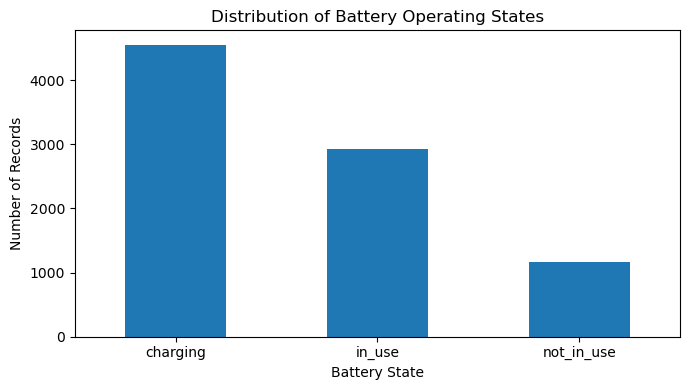

In [8]:
plt.figure(figsize=(7, 4))
state_counts.plot(kind='bar')
plt.title('Distribution of Battery Operating States')
plt.xlabel('Battery State')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Missing-Value Analysis

Missing values are examined before further analysis so that we can understand which measurements contain gaps and whether missingness is concentrated in particular variables.

In [9]:
missing = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Missing Percentage': (df.isna().mean() * 100).round(2)
}).sort_values('Missing Values', ascending=False)

missing

,Missing Values,Missing Percentage
current_A,462,5.35
soc_percent,437,5.06
speed_kph,430,4.98
ambient_temp_C,422,4.88
voltage_V,420,4.86
state_of_health,415,4.80
timestamp,0,0.00
battery_id,0,0.00
state,0,0.00


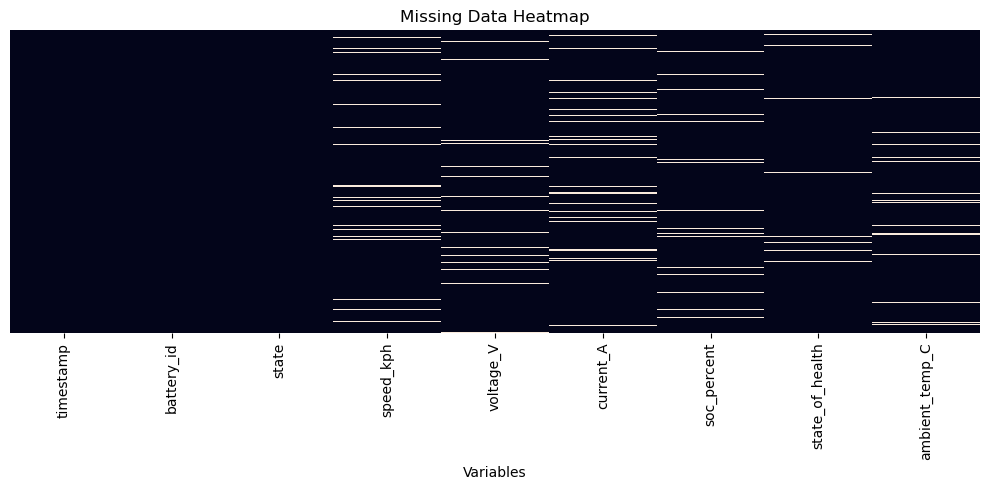

In [10]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Missing Data Heatmap')
plt.xlabel('Variables')
plt.tight_layout()
plt.show()

### Missing-data observation

The missing-value analysis shows where telemetry gaps occur. These gaps should be considered when interpreting patterns in the sensor measurements. At this stage, **no imputation or deletion is performed**, because that belongs to the Data Preparation phase.

## 5. Descriptive Statistics

Descriptive statistics provide an initial understanding of the central tendency and spread of the numerical battery measurements.

In [11]:
numeric_cols = [
    'speed_kph', 'voltage_V', 'current_A',
    'soc_percent', 'state_of_health', 'ambient_temp_C'
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
speed_kph,8210.0,12.229652,20.238704,0.000000,0.000000,0.000000,20.736513,70.000000
voltage_V,8220.0,55.110780,2.798374,43.203356,53.895694,55.245289,57.618162,62.470618
current_A,8178.0,4.322623,2.160957,0.000000,3.350803,4.713204,5.646958,12.821402
soc_percent,8203.0,74.916869,24.814635,6.538179,66.811842,80.010728,95.066590,99.903234
state_of_health,8225.0,88.733623,11.578112,66.851481,80.415094,93.074652,97.806622,98.407328
ambient_temp_C,8218.0,26.817590,1.840609,24.000000,25.271295,26.841338,27.986413,31.884817


## 6. State of Charge (SOC) Over Time

SOC is examined over time for each battery to understand how charge levels behave during the recorded period and whether some batteries show visibly different patterns.

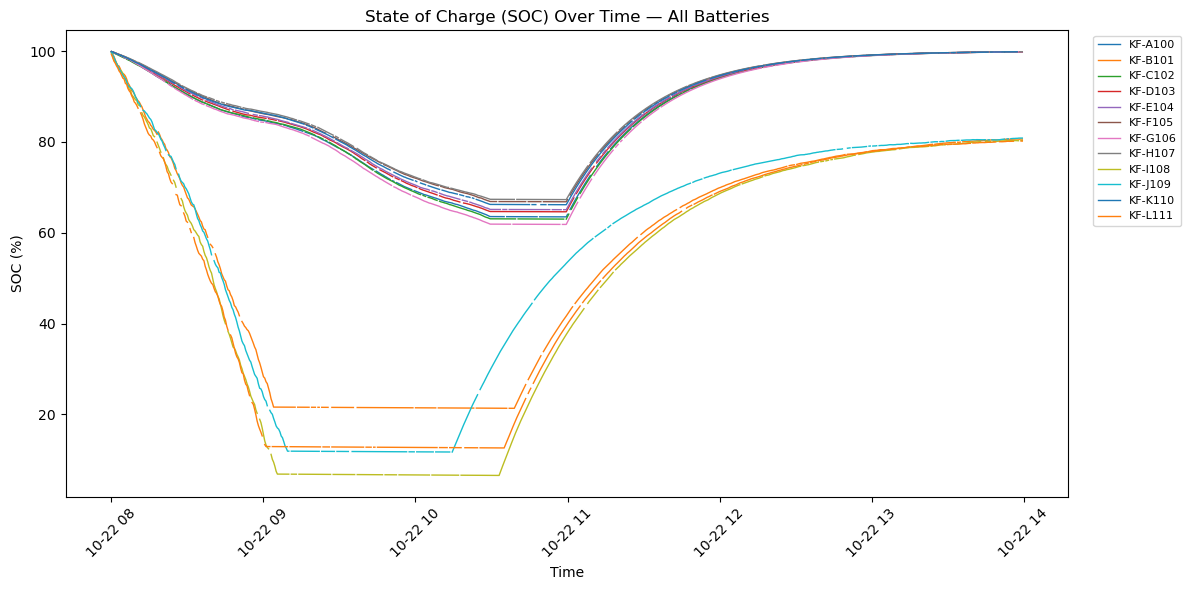

In [12]:
plt.figure(figsize=(12, 6))

for battery_id, group in df.groupby('battery_id'):
    plt.plot(group['timestamp'], group['soc_percent'], label=battery_id, linewidth=1)

plt.title('State of Charge (SOC) Over Time — All Batteries')
plt.xlabel('Time')
plt.ylabel('SOC (%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. State of Health (SOH) Distribution

SOH provides an indication of the reported health condition of the batteries. Examining its distribution helps identify variation between batteries.

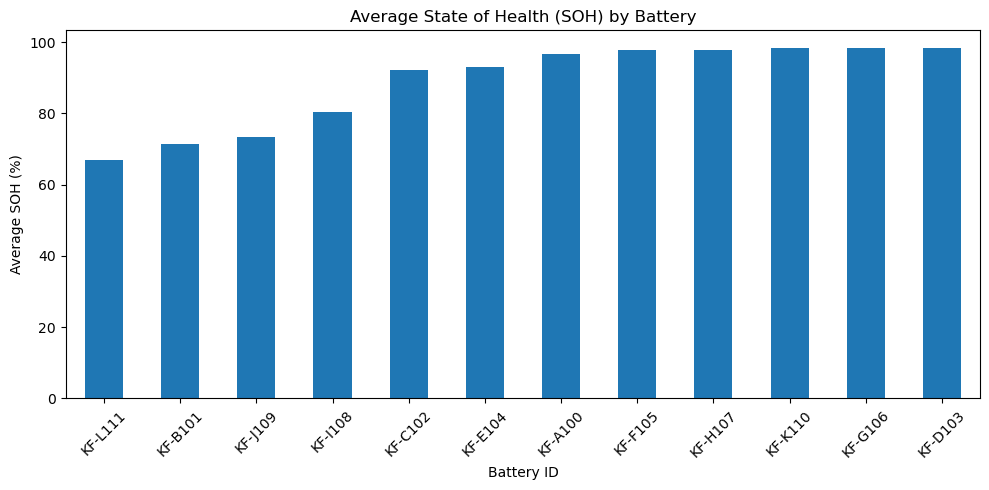

In [13]:
soh_by_battery = df.groupby('battery_id')['state_of_health'].mean().sort_values()

plt.figure(figsize=(10, 5))
soh_by_battery.plot(kind='bar')
plt.title('Average State of Health (SOH) by Battery')
plt.xlabel('Battery ID')
plt.ylabel('Average SOH (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

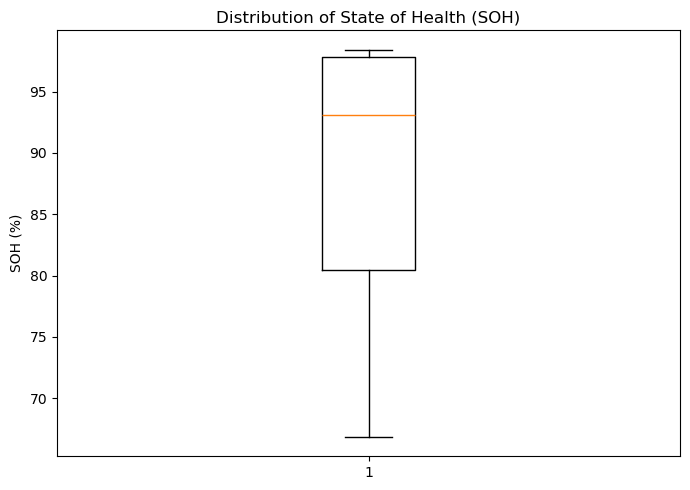

In [14]:
plt.figure(figsize=(7, 5))
plt.boxplot(df['state_of_health'].dropna())
plt.title('Distribution of State of Health (SOH)')
plt.ylabel('SOH (%)')
plt.tight_layout()
plt.show()

## 8. Sensor-Channel Correlation

The correlation matrix shows the strength and direction of linear relationships between the numerical sensor channels. This is useful for understanding how measurements move together before modelling.

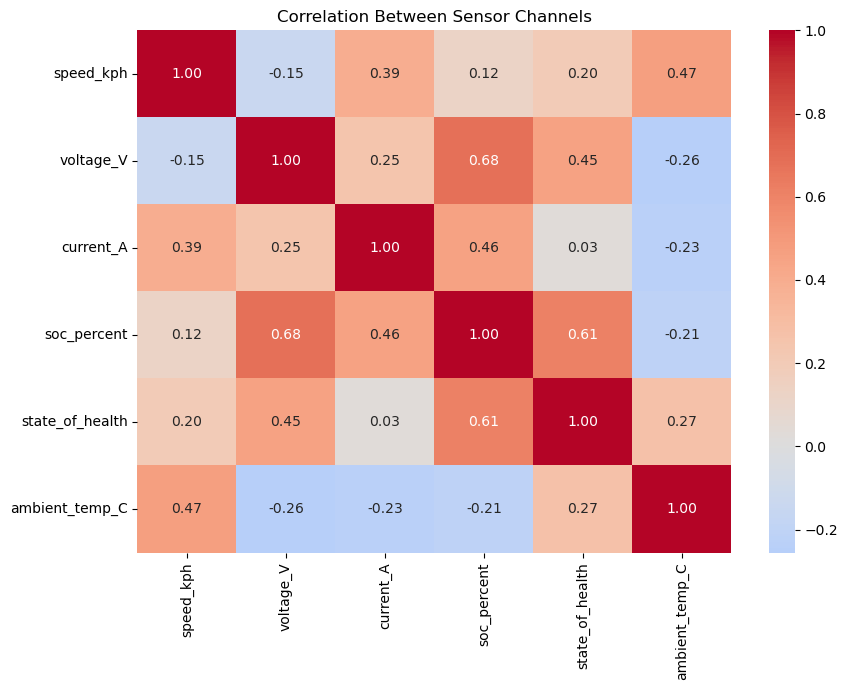

In [15]:
correlation_cols = [
    'speed_kph', 'voltage_V', 'current_A',
    'soc_percent', 'state_of_health', 'ambient_temp_C'
]

corr = df[correlation_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Sensor Channels')
plt.tight_layout()
plt.show()

## 9. Data Understanding — Key Observations

From the exploratory inspection above, we can summarize the main characteristics of the dataset:

- The dataset contains telemetry from **12 Kore2 batteries**.
- The data covers multiple operating states, including `in_use`, `charging`, and `not_in_use`.
- The measurements include speed, voltage, current, SOC, SOH, and ambient temperature.
- Missing values are present in some telemetry measurements and should be addressed during **Data Preparation**, not in this phase.
- SOC trends allow the batteries' charge behaviour to be visually compared over time.
- SOH varies between batteries, providing an initial indication that battery health is not identical across the fleet.
- The correlation matrix provides an initial view of relationships between the numerical sensor channels.

These observations describe the data and highlight areas that may require further investigation. They do **not** constitute modelling, evaluation, or recommendations.